In [1]:
import pandas as pd
import matplotlib.pyplot as plt

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


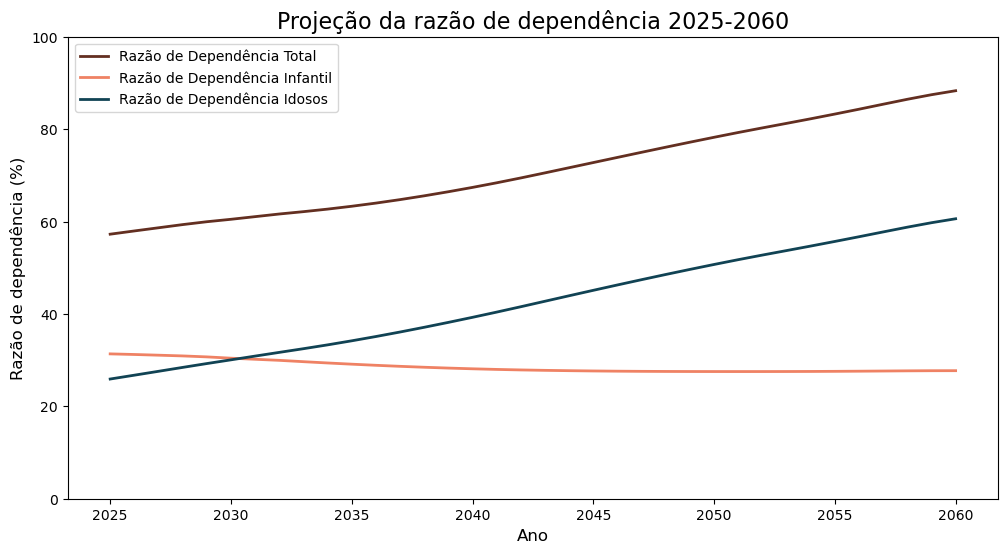

In [10]:
df = pd.read_excel("razao_dependencia.xlsx")

df['criancas'] = df[['0 a 4 anos', '5 a 9 anos', '10 a 14 anos']].sum(axis=1)

df['idosos'] = df[['60 a 64 anos', '65 a 69 anos', '70 a 74 anos', '75 a 79 anos', '80 anos ou mais']].sum(axis=1)

df['produtiva'] = df[['15 a 19 anos', '20 a 24 anos', '25 a 29 anos', '30 a 34 anos',
                      '35 a 39 anos', '40 a 44 anos', '45 a 49 anos', '50 a 54 anos',
                      '55 a 59 anos']].sum(axis=1)

# Razões de dependência
df['rd_total'] = (df['criancas'] + df['idosos']) / df['produtiva'] * 100
df['rd_infantil'] = df['criancas'] / df['produtiva'] * 100
df['rd_idosos'] = df['idosos'] / df['produtiva'] * 100

plt.figure(figsize=(12,6))

linha_total, = plt.plot(teste['Ano'], teste['rd_total'], label='Razão de Dependência Total', color='#632F21', linewidth=2)
linha_infantil, = plt.plot(teste['Ano'], teste['rd_infantil'], label='Razão de Dependência Infantil', color='#EF8264', linewidth=2)
linha_idosos, = plt.plot(teste['Ano'], teste['rd_idosos'], label='Razão de Dependência Idosos', color='#114354', linewidth=2)

plt.title('Projeção da razão de dependência 2025-2060', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Razão de dependência (%)', fontsize=12)

plt.grid(False)

plt.ylim(0, 100)

plt.legend(handles=[linha_total, linha_infantil, linha_idosos])

plt.show()



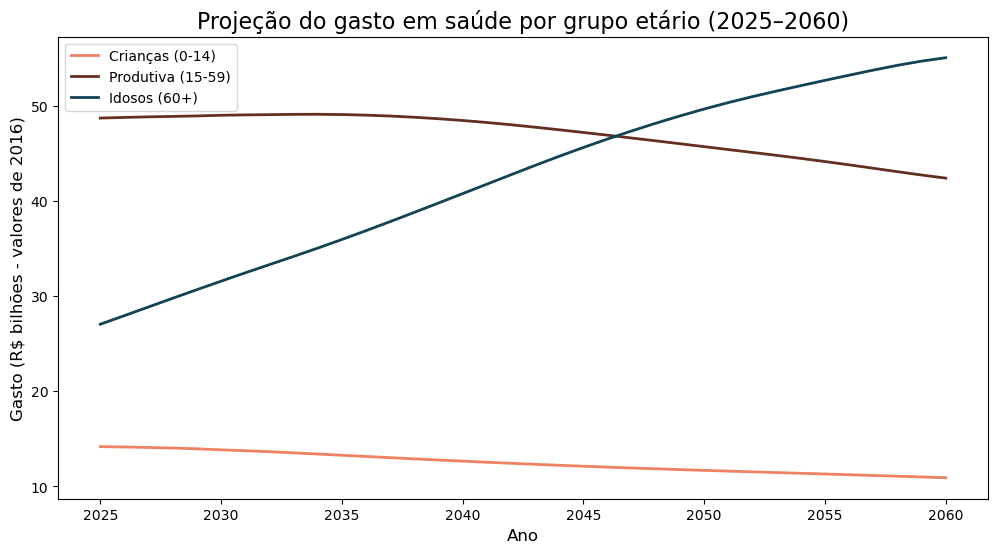

In [18]:
custo_criancas  = 325   # R$ por criança (0–14 anos)
custo_produtiva = 350   # R$ por pessoa em idade produtiva (15–59 anos)
custo_idosos    = 750   # R$ por idoso (60+)


df['gasto_criancas']  = df['criancas']   * custo_criancas
df['gasto_produtiva'] = df['produtiva']  * custo_produtiva
df['gasto_idosos']    = df['idosos']     * custo_idosos

df['gasto_total'] = df['gasto_criancas'] + df['gasto_produtiva'] + df['gasto_idosos']

# em bilhões para facilitar visualização
df['gasto_total_bi'] = df['gasto_total'] / 1e9

plt.figure(figsize=(12,6))

plt.plot(df['Ano'], df['gasto_criancas']/1e9, label='Crianças (0-14)', color='#EF8264', linewidth=2)
plt.plot(df['Ano'], df['gasto_produtiva']/1e9, label='Produtiva (15-59)', color='#632F21', linewidth=2)
plt.plot(df['Ano'], df['gasto_idosos']/1e9, label='Idosos (60+)', color='#114354', linewidth=2)

plt.title('Projeção do gasto em saúde por grupo etário (2025–2060)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Gasto (R$ bilhões - valores de 2016)', fontsize=12)

plt.legend()
plt.show()



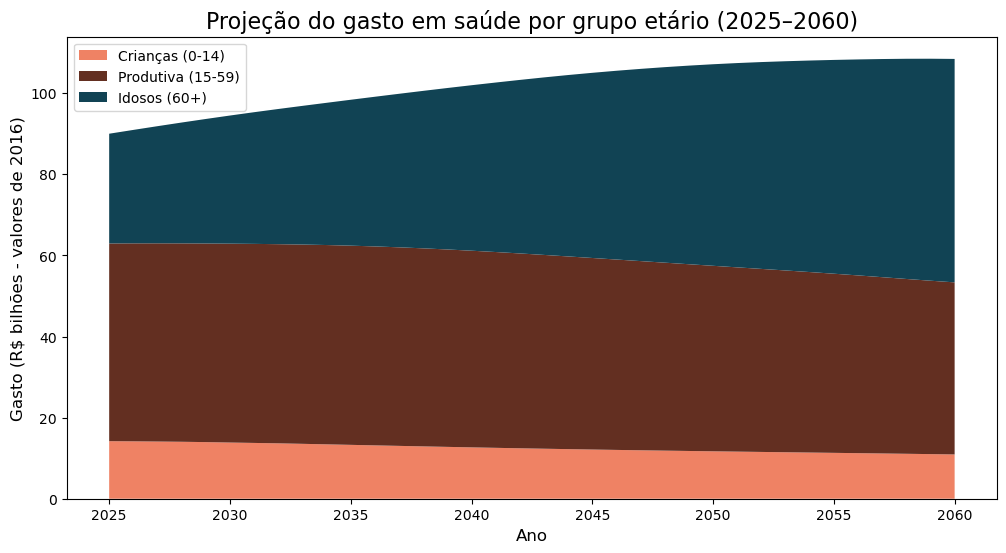

In [19]:
import matplotlib.pyplot as plt

# Dados empilhados
gastos = [df['gasto_criancas']/1e9, df['gasto_produtiva']/1e9, df['gasto_idosos']/1e9]
labels = ['Crianças (0-14)', 'Produtiva (15-59)', 'Idosos (60+)']
colors = ['#EF8264', '#632F21', '#114354']

plt.figure(figsize=(12,6))
plt.stackplot(df['Ano'], gastos, labels=labels, colors=colors)

plt.title('Projeção do gasto em saúde por grupo etário (2025–2060)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Gasto (R$ bilhões - valores de 2016)', fontsize=12)
plt.legend(loc='upper left')

plt.show()
